# This code is used to address the reviewer's comments on paper 2, specifically on the hypothesis testing
2025.9.5
Mu-Ting Chien

In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

In [5]:
DIR                    = '/barnes-engr-scratch1/c832572266/'
file_dir_multi_yr      = DIR + 'data_output/ace2/obs_compare_with_ace2/'
file_dir_multi_yr_ace2 = DIR + 'data_output/ace2/ace2_output/10yr/'
file_dir_multi_yr_ace2_100yr = DIR + 'data_output/ace2/ace2_output/repeat_2001-2010/'
pi                     = np.pi

In [24]:
sub_dir = list(['2001','2002','2003','2004','2005','2006','2007','2008','2009','2010'])
nrun = 10000 # How many times of rnadom selection for null hypothesis

In [25]:
# Mutual bin for TC genesis lag KW crest
hr_bin = np.arange(-126, 126, 6)+3
hr_bin_12h = np.arange(-132, 144, 12)+6
hr_bin_daily = np.arange(-8.5, 9.5, 1)

In [26]:
# Load basin info
basin_list    = list(['NI','NWPAC','NEPAC','NATL','SI','SPAC'])
basin_long_list = list(['North IO','North WestPac','North EastPac','North Atl','South IO','South Pac'])
basin_lon_min = np.array([45, 105, 180, 265, 35, 135])
basin_lon_max = np.array([105, 180, 265, 357.5, 135, 270])
latmax = 30 #25 is not used, use 30
basin_lat_min = np.array([0,    0,    0,  0,  -latmax, -latmax])
basin_lat_max = np.array([latmax,  latmax, latmax, latmax,    0, 0])
nbasin        = np.size(basin_list)

# Load the TC genesis data and KW data for 2001-2010 (start here!)

In [6]:
'''
# Load KW phase data (for each latitude)
data          = np.load(file_dir_multi_yr_ace2+'pr_kw-phase_ace2.npz')
phase_correct_ace2 = data['phase_correct']
time_filt_ace2     = data['time_filt']
#time_phase_ace2 = time_ace2[time_filt]
lon_ace2 = data['lon']
lat_ace2 = data['lat_15SN']


data = np.load(file_dir_multi_yr+'pr_kw-phase_imerg_2001-2010.npz')
phase_correct_obs = data['phase_correct']
time_filt_obs     = data['time_filt']
#time_phase_imerg    = time[time_filt_imerg]
lat_obs           = data['lat_15SN']
lon_obs           = data['lon']
'''

# Load KW phase data (for 0-10N, 0-10S)
data = np.load(file_dir_multi_yr+'pr_kw-phase_imerg_2001-2010_10SN.npz')
phase_correct_obs_10S = data['phase_correct_10S']
phase_correct_obs_10N = data['phase_correct_10N']

# Find KW crest (the enhanced KW phase)
#KW_crest_ace2 = np.where(phase_correct_ace2==-pi/2, 1, 0)
KW_crest_obs_10S = np.where(phase_correct_obs_10S==-pi/2, 1, 0)
KW_crest_obs_10N = np.where(phase_correct_obs_10N==-pi/2, 1, 0)

# Load TC data
data = np.load(file_dir_multi_yr+'TCgenesis_associate_with_tropical_wave_phase.npz')
TC_genesis_txy_ace2 = data['TC_genesis_txy'] # code above this section sets this variable as TC_genesis_txy
it_ace2         = data['it']
ilat_ace2       = data['ilat']
ilon_ace2       = data['ilon']
#
data = np.load(file_dir_multi_yr+'TCgenesis_associate_with_tropical_wave_phase_imerg-era5.npz')
TC_genesis_txy_obs = data['TC_genesis_txy']
it_obs    = data['it']
ilat_obs  = data['ilat']
ilon_obs  = data['ilon']

In [8]:
print(np.shape(KW_crest_ace2))

(13870, 30, 360)


# Load the TC genesis and KW data for ACE2-100yr

In [ ]:
for isub in range(0, nsub):
    yrname = sub_dir[isub]
    data = np.load(file_dir_multi_yr_ace2_100yr+'TC_genesis_30SN/TCgenesis_associate_with_KW_phase_'+yrname+'.npz')
    TC_genesis_txy_ace2_100yr = data['TC_genesis_txy']

    # Load KW phase data (same as previous code)
    data = np.load(file_dir_sub+'pr_kw-phase_ace2_'+yrname+'_10yr_10SN.npz')
    phase_correct_ace2_10SN = data['phase_correct_ace2_10SN']
    phase_correct_ace2_10S  = data['phase_correct_ace2_10S']
    phase_correct_ace2_10N  = data['phase_correct_ace2_10N']

    #time_phase_ace2 = time_ace2[time_filt]
    lon_ace2 = data['lon']
    lat_ace2 = lat_15SN_ace2

    #phase_correct = phase_correct_ace2_10SN

    # Find KW crest (the enhanced KW phase)
    KW_crest_ace2_10S = np.where(phase_correct_ace2_10S==-pi/2, 1, 0)
    KW_crest_ace2_10N = np.where(phase_correct_ace2_10N==-pi/2, 1, 0)


# Reorganize the data into each KW peak (year, mon, day, hr, lat, lon) - 10 year

In [10]:
kw_peak_txy_ace2 = np.where(phase_correct_ace2==-pi/2, 1, 0)
kw_peak_txy_obs = np.where(phase_correct_obs==-pi/2, 1, 0)

In [62]:
print(np.shape(kw_peak_txy_obs))

(13878, 31, 360)


In [61]:
print(np.shape(kw_peak_txy_ace2))

(13870, 30, 360)


# For each TC genesis event, randomly select the same day of a different years, calculate the KW lag days - 10 yr
This process will be repeated for 10,000 times to create the random distribution

In [21]:
# Choose a random year from 0 to 9
iyr_random = np.random.choice(np.arange(0, 10), nrun, replace=True)

# Loop through each TC genesis event
for i in range(0, np.size(it_obs)): # Change this to ACE2 LATER !

    for irun in range(0, nrun): # Should be 100 runs

        it_random = np.mod(it_obs, 365*4)+365*4*iyr_random[irun] # Change this to ACE2 LATER !

        # Find the lag day of the nearest KW peak at it_random (start here!): 32 comes from 8 days before and after the "fake" genesis time
        kw_peak_random_before = kw_peak_txy_obs[it_random[i]-32: it_random[i], :, :]
        kw_peak_random_after  = kw_peak_txy_obs[it_random[i]: it_random[i]+32, :, :]

        # Find the KWs before the TC genesis
        ikw = np.argwhere(kw_peak_random_before[:, ilat_obs[i], ilon_obs[i]]==1).squeeze()
        if np.size(ikw)>0:
            it_before = np.nanmax(ikw)
        else:
            it_before = np.nan
        #print('it_before:',it_before)
        
        # Find the KWs after the TC genesis
        ikw = np.argwhere(kw_peak_random_after[:, ilat_obs[i], ilon_obs[i]]==1).squeeze()
        if np.size(ikw)>0:
            it_after = np.nanmin(ikw)
        else:
            it_after = np.nan
        #print('it_after:',it_after)

        # Find the lag days of the nearest KW peak
        lags = np.arange(32, -33, -1)

        if i == 0 and irun == 0:
            lag_days_obs = np.zeros([np.size(it_random), nrun])
            lag_days_obs[:] = np.nan

        #if np.isnan(it_before)==0:
        #    print('lags before:',lags[it_before])
        #if np.isnan(it_after)==0:
        #    print('lags after:',lags[it_after+32])

        if np.isnan(it_before) == 1 and np.isnan(it_after) == 1:
            lag_days_obs[i, irun] = np.nan
        elif np.isnan(it_before) == 1:
            lag_days_obs[i, irun] = lags[it_after+32]
        elif np.isnan(it_after) == 1:
            lag_days_obs[i, irun] = lags[it_before]
        elif np.abs(lags[it_before] ) < np.abs(lags[it_after+32]):
            lag_days_obs[i, irun] = lags[it_before]
        else:
            lag_days_obs[i, irun] = lags[it_after+32]

        if np.mod(irun, 100)==0:
            print('lag_days:',lag_days_obs[i, irun]/4)

lag_days: 2.5
lag_days: 2.5
lag_days: 2.5
lag_days: 2.25
lag_days: nan
lag_days: nan
lag_days: -4.5
lag_days: 5.25
lag_days: 2.5
lag_days: 5.25
lag_days: -3.75
lag_days: 0.5
lag_days: -3.75
lag_days: 2.5
lag_days: nan
lag_days: 2.0
lag_days: -3.75
lag_days: 2.25
lag_days: 5.25
lag_days: -3.75
lag_days: 2.0
lag_days: 2.5
lag_days: -2.0
lag_days: nan
lag_days: -2.0
lag_days: nan
lag_days: nan
lag_days: -2.0
lag_days: -4.5
lag_days: 5.25
lag_days: 5.25
lag_days: nan
lag_days: nan
lag_days: nan
lag_days: 2.5
lag_days: 2.25
lag_days: 2.5
lag_days: nan
lag_days: -2.0
lag_days: 5.25
lag_days: -4.5
lag_days: nan
lag_days: 0.5
lag_days: 5.25
lag_days: 2.5
lag_days: -3.75
lag_days: 2.25
lag_days: -2.0
lag_days: 0.5
lag_days: 3.0
lag_days: 5.25
lag_days: -3.75
lag_days: -4.5
lag_days: 0.5
lag_days: 5.25
lag_days: -4.5
lag_days: 0.5
lag_days: -4.5
lag_days: nan
lag_days: 5.25
lag_days: nan
lag_days: 3.0
lag_days: -2.0
lag_days: -3.75
lag_days: 5.25
lag_days: 0.5
lag_days: 5.25
lag_days: 2.25
lag_d

In [64]:
# Loop through each TC genesis event (NEED TO CHANGE THIS TO 100 YEAR!)
iyr_random = np.random.choice(np.arange(0, 10), nrun, replace=True)
for i in range(0, np.size(it_ace2)): # Change this to ACE2 LATER !

    for irun in range(0, nrun): # Should be 100 runs

        it_random = np.mod(it_ace2, 365*4)+365*4*iyr_random[irun] # Change this to ACE2 LATER !

        # Find the lag day of the nearest KW peak at it_random (start here!): 32 comes from 8 days before and after the "fake" genesis time
        kw_peak_random_before = kw_peak_txy_ace2[it_random[i]-32: it_random[i], :, :]
        kw_peak_random_after  = kw_peak_txy_ace2[it_random[i]: it_random[i]+32, :, :]

        # Find the KWs before the TC genesis
        ikw = np.argwhere(kw_peak_random_before[:, ilat_ace2[i], ilon_ace2[i]]==1).squeeze()
        if np.size(ikw)>0:
            it_before = np.nanmax(ikw)
        else:
            it_before = np.nan
        #print('it_before:',it_before)
        
        # Find the KWs after the TC genesis
        ikw = np.argwhere(kw_peak_random_after[:, ilat_ace2[i], ilon_ace2[i]]==1).squeeze()
        if np.size(ikw)>0:
            it_after = np.nanmin(ikw)
        else:
            it_after = np.nan
        #print('it_after:',it_after)

        # Find the lag days of the nearest KW peak
        lags = np.arange(32, -33, -1)

        if i == 0 and irun == 0:
            lag_days_ace2 = np.zeros([np.size(it_random), nrun])
            lag_days_ace2[:] = np.nan

        #if np.isnan(it_before)==0:
        #    print('lags before:',lags[it_before])
        #if np.isnan(it_after)==0:
        #    print('lags after:',lags[it_after+32])

        if np.isnan(it_before) == 1 and np.isnan(it_after) == 1:
            lag_days_ace2[i, irun] = np.nan
        elif np.isnan(it_before) == 1:
            lag_days_ace2[i, irun] = lags[it_after+32]
        elif np.isnan(it_after) == 1:
            lag_days_ace2[i, irun] = lags[it_before]
        elif np.abs(lags[it_before] ) < np.abs(lags[it_after+32]):
            lag_days_ace2[i, irun] = lags[it_before]
        else:
            lag_days_ace2[i, irun] = lags[it_after+32]

        if np.mod(irun, 100)==0:
            print('lag_days:',lag_days_ace2[i, irun]/4)

lag_days: 3.75
lag_days: nan
lag_days: 3.5
lag_days: 7.0
lag_days: 7.0
lag_days: 0.75
lag_days: nan
lag_days: 3.75
lag_days: 0.75
lag_days: 3.75
lag_days: nan
lag_days: nan
lag_days: 7.0
lag_days: 0.75
lag_days: 0.75
lag_days: nan
lag_days: nan
lag_days: 7.0
lag_days: nan
lag_days: nan
lag_days: 6.5
lag_days: 6.5
lag_days: 7.0
lag_days: nan
lag_days: nan
lag_days: 6.5
lag_days: nan
lag_days: nan
lag_days: nan
lag_days: nan
lag_days: 3.5
lag_days: 0.75
lag_days: nan
lag_days: nan
lag_days: 0.75
lag_days: nan
lag_days: nan
lag_days: nan
lag_days: 6.5
lag_days: nan
lag_days: 3.75
lag_days: 6.5
lag_days: 3.5
lag_days: nan
lag_days: nan
lag_days: nan
lag_days: 3.5
lag_days: nan
lag_days: nan
lag_days: nan
lag_days: nan
lag_days: 3.75
lag_days: 0.75
lag_days: 7.0
lag_days: nan
lag_days: nan
lag_days: nan
lag_days: nan
lag_days: 3.75
lag_days: nan
lag_days: 6.5
lag_days: 6.5
lag_days: 3.5
lag_days: nan
lag_days: nan
lag_days: nan
lag_days: 6.5
lag_days: nan
lag_days: nan
lag_days: 7.0
lag_day

# Try plotting the results of the random distribution - 10 yr

1. Load TC genesis event for each ocean basin

In [22]:
# Load basin index for each TC genesis event
filename = 'TCgenesis_associate_with_tropical_wave_phase'
fname_list = list(['','_imerg-era5'])

data = np.load(file_dir_multi_yr + filename + fname_list[0]+'.npz')
basin_idx_ace2 = data['basin_idx']

data = np.load(file_dir_multi_yr + filename + fname_list[1]+'.npz')
basin_idx_obs = data['basin_idx']

2. Classify the global lag days above into each basin

In [28]:
# repeat basin_idx
basin_idx_ace2_repeat = np.tile(basin_idx_ace2, (nrun, 1)).T
print(np.shape(basin_idx_ace2_repeat))   

(483, 10000)


In [33]:
# Check the size of TC genesis arrays are the same for basin index and actual number of genesis
if np.size(basin_idx_obs) != np.size(it_obs):
    print('Error: basin_idx_obs and it_obs have different sizes!')
if np.size(basin_idx_ace2) != np.size(it_ace2):
    print('Error: basin_idx_ace2 and it_ace2 have different sizes!')

# Plot histogram of lag days for each basin
dhr_basin0_ace2 = np.where(basin_idx_ace2_repeat==0, lag_days_ace2*6,  np.nan)
dhr_basin0_ace2 = dhr_basin0_ace2[np.isnan(dhr_basin0_ace2)==0]
#
dhr_basin1_ace2 = np.where(basin_idx_ace2_repeat==1, lag_days_ace2*6,  np.nan)
dhr_basin1_ace2 = dhr_basin1_ace2[np.isnan(dhr_basin1_ace2)==0]
#
dhr_basin2_ace2 = np.where(basin_idx_ace2_repeat==2, lag_days_ace2*6,  np.nan)
dhr_basin2_ace2 = dhr_basin2_ace2[np.isnan(dhr_basin2_ace2)==0]
#
dhr_basin3_ace2 = np.where(basin_idx_ace2_repeat==3, lag_days_ace2*6,  np.nan)
dhr_basin3_ace2 = dhr_basin3_ace2[np.isnan(dhr_basin3_ace2)==0]
#
dhr_basin4_ace2 = np.where(basin_idx_ace2_repeat==4, lag_days_ace2*6,  np.nan)
dhr_basin4_ace2 = dhr_basin4_ace2[np.isnan(dhr_basin4_ace2)==0]
#
dhr_basin5_ace2 = np.where(basin_idx_ace2_repeat==5, lag_days_ace2*6,  np.nan)
dhr_basin5_ace2 = dhr_basin5_ace2[np.isnan(dhr_basin5_ace2)==0]

NameError: name 'lag_days_ace2' is not defined

In [29]:
# repeat basin_idx
basin_idx_obs_repeat = np.tile(basin_idx_obs, (nrun, 1)).T
print(np.shape(basin_idx_obs_repeat))   

(538, 10000)


In [31]:
# Plot histogram of lag days for each basin
dhr_basin0_obs = np.where(basin_idx_obs_repeat==0, lag_days_obs*6,  np.nan)
dhr_basin0_obs = dhr_basin0_obs[np.isnan(dhr_basin0_obs)==0]
#
dhr_basin1_obs = np.where(basin_idx_obs_repeat==1, lag_days_obs*6,  np.nan)
dhr_basin1_obs = dhr_basin1_obs[np.isnan(dhr_basin1_obs)==0]
#
dhr_basin2_obs = np.where(basin_idx_obs_repeat==2, lag_days_obs*6,  np.nan)
dhr_basin2_obs = dhr_basin2_obs[np.isnan(dhr_basin2_obs)==0]
#
dhr_basin3_obs = np.where(basin_idx_obs_repeat==3, lag_days_obs*6,  np.nan)
dhr_basin3_obs = dhr_basin3_obs[np.isnan(dhr_basin3_obs)==0]
#
dhr_basin4_obs = np.where(basin_idx_obs_repeat==4, lag_days_obs*6,  np.nan)
dhr_basin4_obs = dhr_basin4_obs[np.isnan(dhr_basin4_obs)==0]
#
dhr_basin5_obs = np.where(basin_idx_obs_repeat==5, lag_days_obs*6,  np.nan)
dhr_basin5_obs = dhr_basin5_obs[np.isnan(dhr_basin5_obs)==0]

3. Plot TC genesis histogram to each lag day

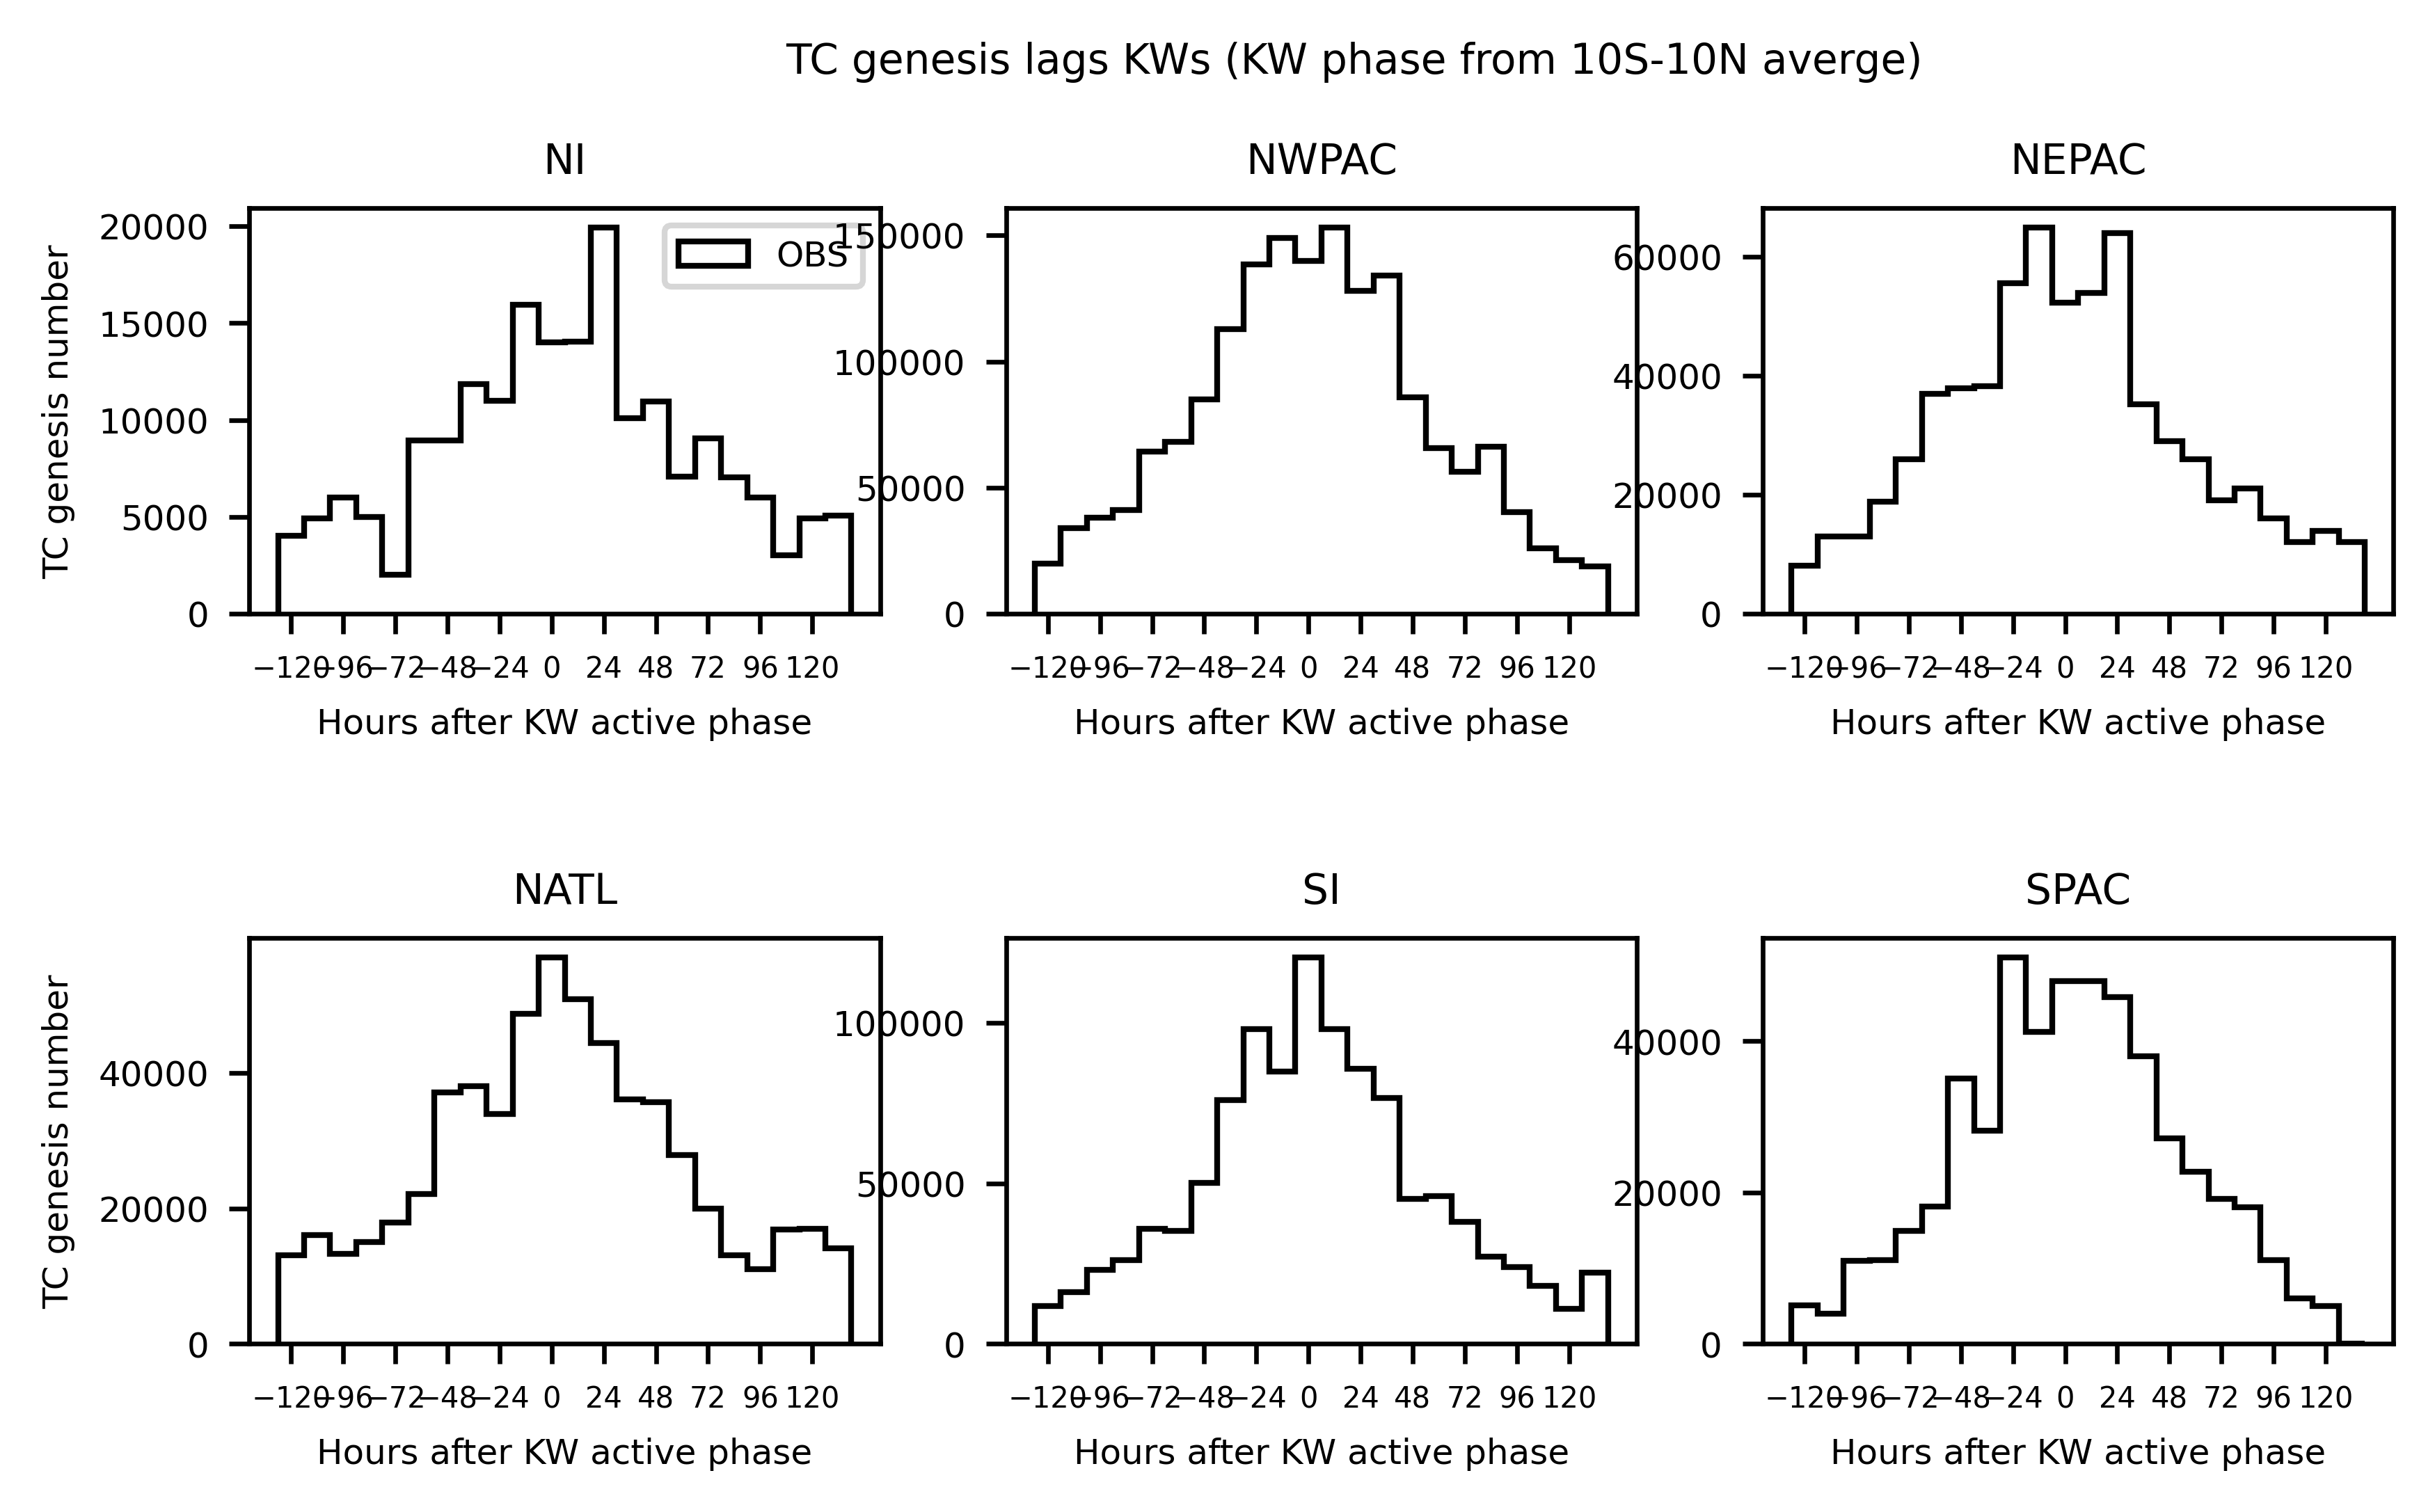

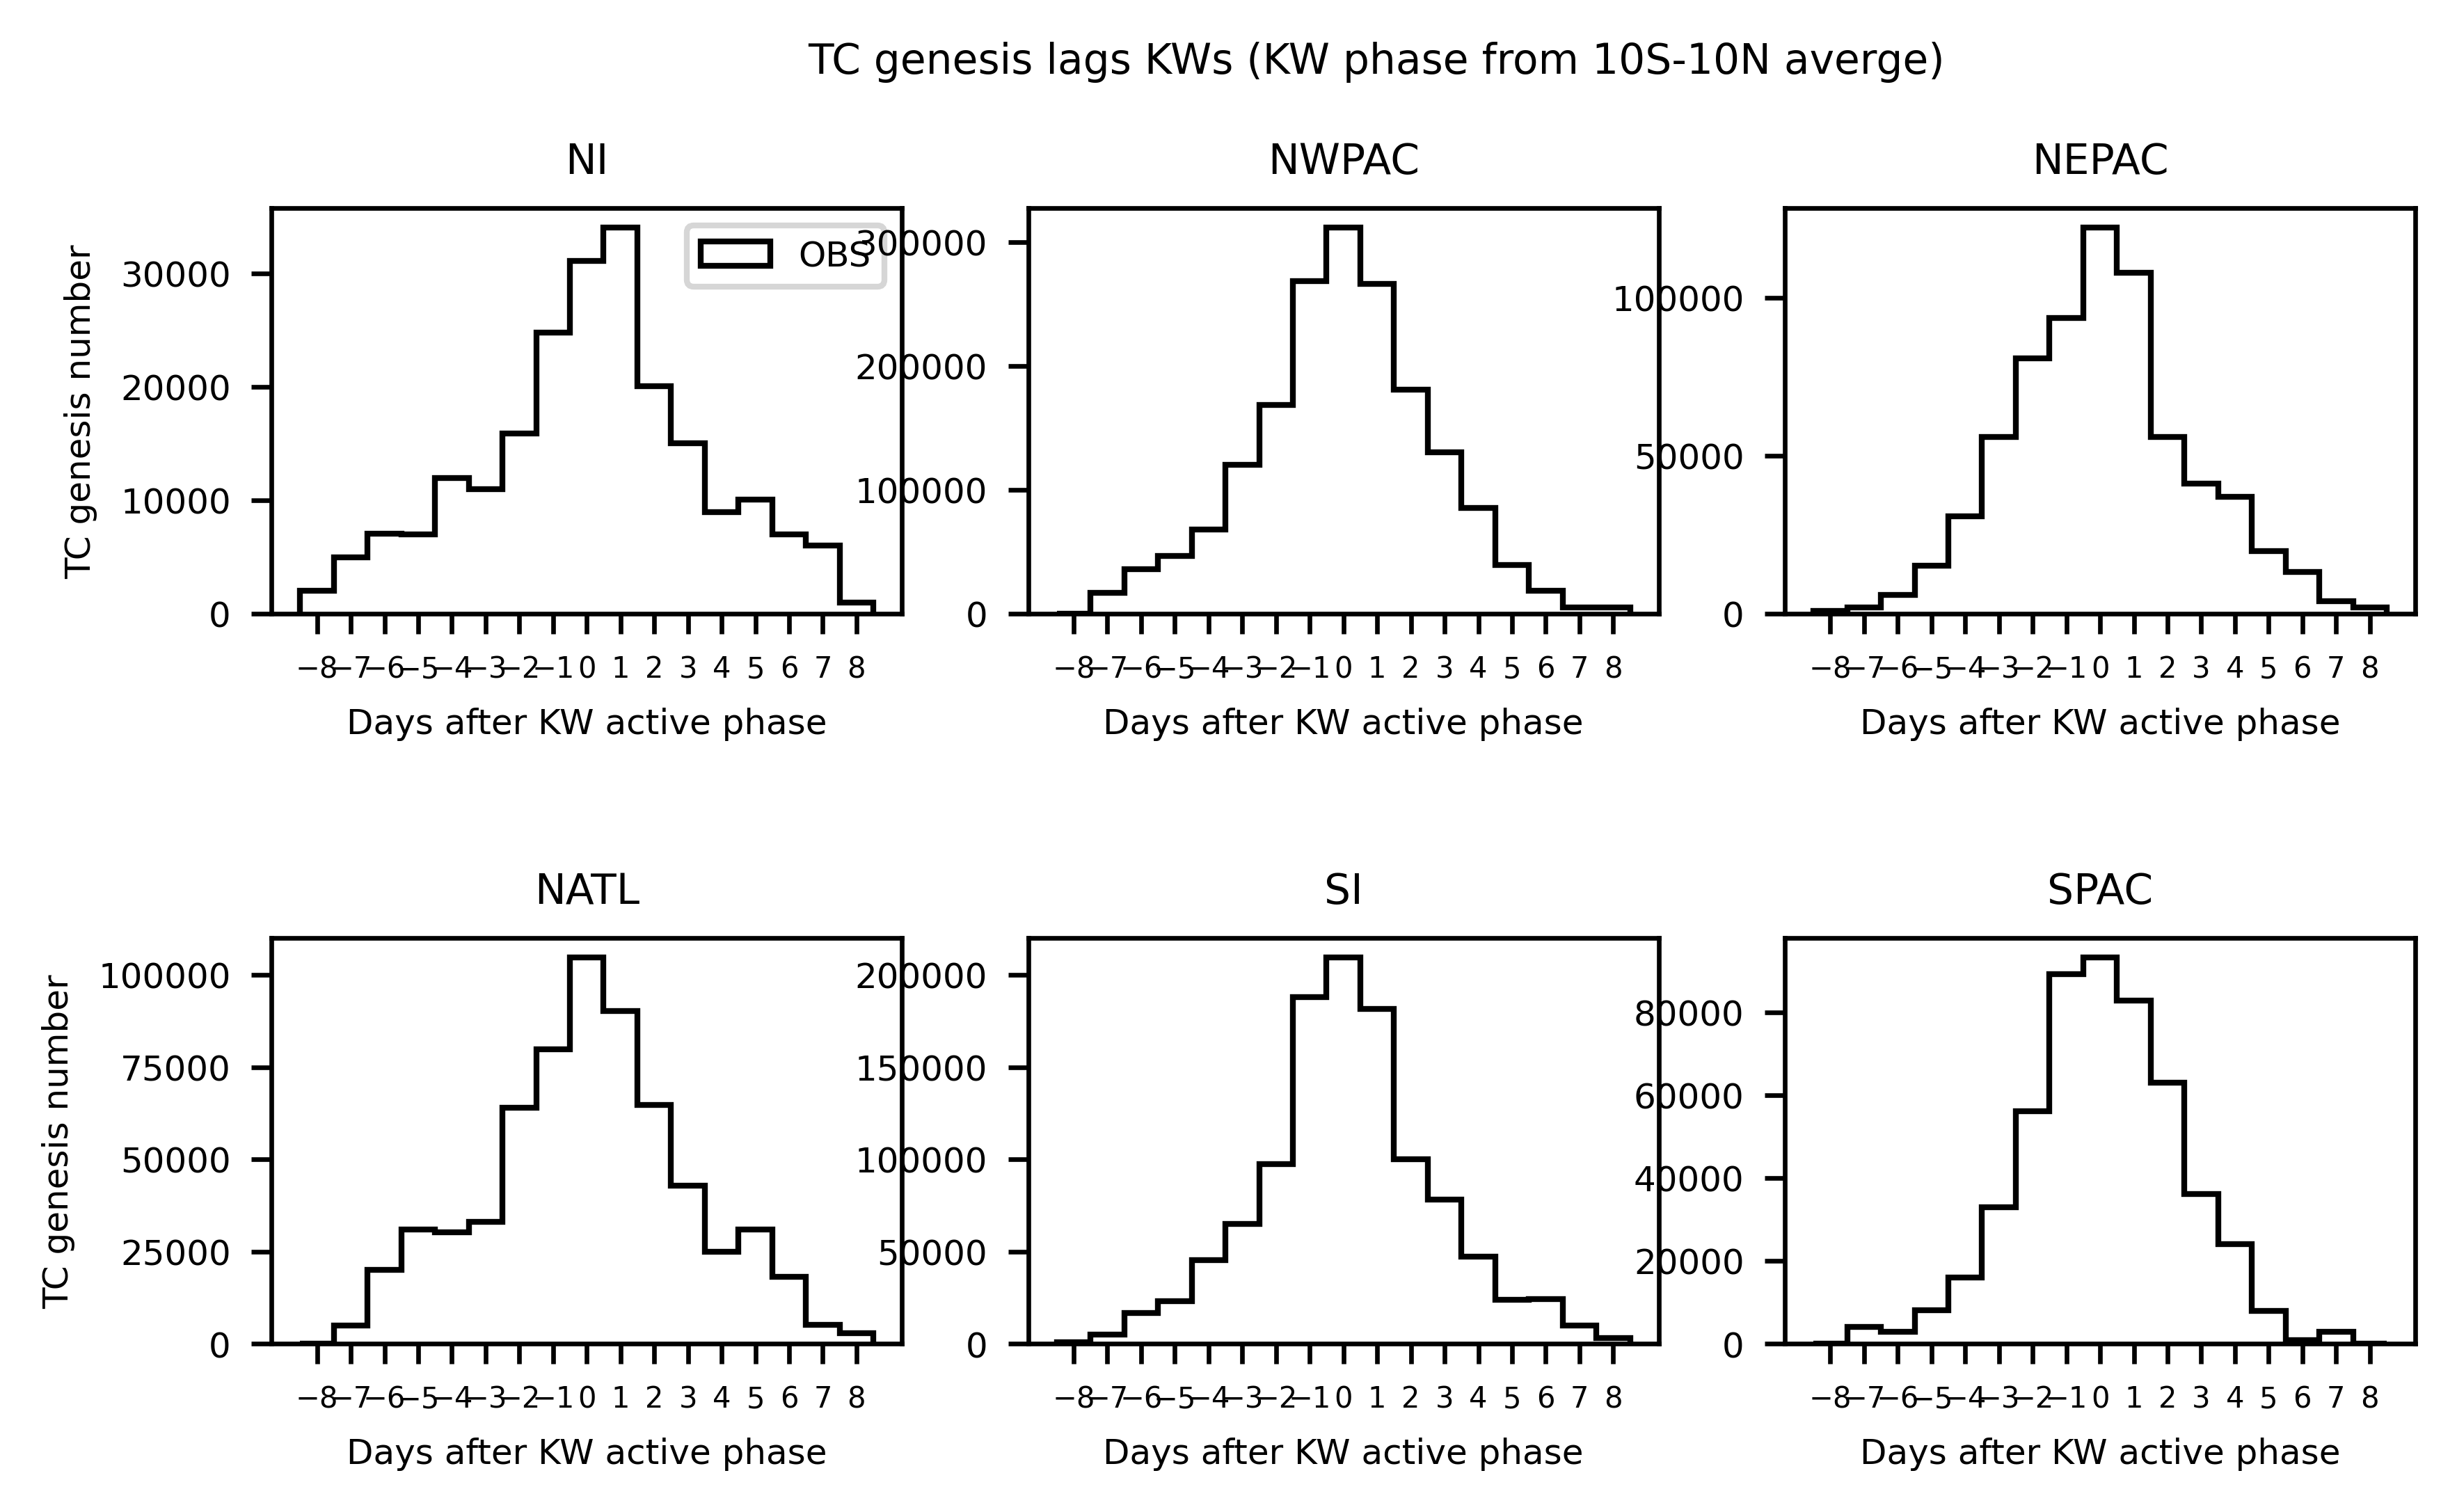

In [35]:
# Plot TC genesis for each basin
nbasin = 6
obs_only = 1 #0 or 1
ace2_only = 0 # 0 or 1
obs_only_list = list(['','_only_obs'])
ace2_only_list = list(['','_only_ace2'])
hr_bin_6h_12h = 1 # or 0 (0: 6h, 1: 12h)
hr_list = list(['','_12h'])
for bin_daily in range(0,2):
    if bin_daily == 0:
        fig_name = 'KW_TCgenesis_laghr_histogram_10SN_each_basin'+obs_only_list[obs_only]+ace2_only_list[ace2_only]+hr_list[hr_bin_6h_12h]+'.png'
    else:
        fig_name = 'KW_TCgenesis_laghr_histogram_10SN_daily_each_basin'+obs_only_list[obs_only]+ace2_only_list[ace2_only]+'.png'
    fig = plt.subplots(2,3,figsize=(6.5, 4),dpi=600)
    plt.subplots_adjust(left=0.2,right=0.99,top=0.88,bottom=0.2, hspace=0.8, wspace=0.2)
    plt.rcParams.update({'font.size': 6})
    zero = np.array([0,0])
    for ibasin in range(0, nbasin):
        plt.subplot(2, 3, ibasin+1)
        #dhr_tmp_ace2 = globals()['dhr_basin'+str(ibasin)+'_ace2']
        dhr_tmp_era5 = globals()['dhr_basin'+str(ibasin)+'_obs']
        if bin_daily == 0:
            if obs_only == 0:
                if hr_bin_6h_12h == 0:
                    plt.hist(dhr_tmp_ace2, hr_bin, color='b',histtype='step')
                    #plt.plot([-117,117], [x_99_ace2_6hr_basin[ibasin], x_99_ace2_6hr_basin[ibasin]], color='dodgerblue', linewidth=0.5, linestyle='dashed')
                else:
                    plt.hist(dhr_tmp_ace2, hr_bin_12h, color='b',histtype='step')
                    #plt.plot([-117,117], [x_99_ace2_12hr_basin[ibasin], x_99_ace2_12hr_basin[ibasin]], color='dodgerblue', linewidth=0.5, linestyle='dashed')
            if ace2_only == 0:
                if hr_bin_6h_12h == 0:
                    plt.hist(dhr_tmp_era5, hr_bin, color='k',label=':',histtype='step')
                    plt.plot([-117,117], [x_99_obs_6hr_basin[ibasin], x_99_obs_6hr_basin[ibasin]], color='grey', linewidth=0.5, linestyle=':')
                else:
                    plt.hist(dhr_tmp_era5, hr_bin_12h, color='k',label=':',histtype='step')
                    #plt.plot([-117,117], [x_99_obs_12hr_basin[ibasin], x_99_obs_12hr_basin[ibasin]], color='grey', linewidth=0.5, linestyle=':')
                #plt.hist(dhr_tmp_era5, hr_bin_12h, color='k',label=':',histtype='step')
                
            plt.xlabel('Hours after KW active phase')
            plt.xticks(np.arange(-120,144,24), fontsize=5)
            plt.plot(zero, [0,11], color='grey',linestyle=':')
        else:
            if obs_only == 0:
                plt.hist(dhr_tmp_ace2/24, hr_bin_daily, color='b',histtype='step')
                #plt.plot([-8,8], [x_99_ace2_basin[ibasin], x_99_ace2_basin[ibasin]], color='dodgerblue', linewidth=0.5, linestyle='dashed')
            if ace2_only == 0:
                plt.hist(dhr_tmp_era5/24, hr_bin_daily, color='k',label=':',histtype='step') 
                #plt.plot([-8,8], [x_99_obs_basin[ibasin], x_99_obs_basin[ibasin]], color='grey', linewidth=0.5, linestyle=':')
            plt.xlabel('Days after KW active phase')
            plt.xticks(np.arange(-8,9,1), fontsize=5)
            #plt.xticks(np.arange(-5,6,1), fontsize=5.5)
            plt.plot(zero, [0,30], color='grey',linestyle=':')
        if ibasin == 0:
            if obs_only == 1:
                plt.legend(['OBS'])
            if ace2_only == 1:
                plt.legend(['ACE2-ERA5'])
            if obs_only == 0 and ace2_only == 0:
                plt.legend(['ACE2-ERA5','OBS'])
        if ibasin == 0 or ibasin == 3:
            plt.ylabel('TC genesis number')
        plt.title(basin_list[ibasin])
    plt.suptitle('                                            TC genesis lags KWs (KW phase from 10S-10N averge)')
    #plt.savefig(fig_dir+fig_name,format='png', dpi=600)
    plt.show()
    plt.close()

# Load real statistics from ACE2 (100yr)

In [47]:
# Aggregate dhr for each basin for 100 years
i0 = 0
i1 = 0
i2 = 0
i3 = 0
i4 = 0
i5 = 0

for first_time_exe in range(1, -1, -1):

    nsub = np.size(sub_dir)
    for isub in range(0, nsub):
        
        # Load ACE2
        yrname = sub_dir[isub]
        data = np.load(file_dir_multi_yr_ace2_100yr+'TC_genesis_30SN/TCgenesis_lag_kwcrest_hr_10SN_'+yrname+'_basin.npz')
        dhr_basin0_ace2_real = data['dhr_ace2_basin0']
        dhr_basin1_ace2_real = data['dhr_ace2_basin1']
        dhr_basin2_ace2_real = data['dhr_ace2_basin2']
        dhr_basin3_ace2_real = data['dhr_ace2_basin3']
        dhr_basin4_ace2_real = data['dhr_ace2_basin4']
        dhr_basin5_ace2_real = data['dhr_ace2_basin5']

        if first_time_exe == 1:
            if isub == 0:
                size_basin_all = np.empty([nsub, nbasin])
            for ibasin in range(0, nbasin):
                tmp = globals()['dhr_basin'+str(ibasin)+'_ace2_real']
                size_basin_all[isub,ibasin] = np.size(tmp)
        else:
            if isub == 0:
                dhr_basin0_ace2_100yr = np.empty([ int(np.sum(size_basin_all[:,0],0)) ])
                dhr_basin1_ace2_100yr = np.empty([ int(np.sum(size_basin_all[:,1],0)) ])
                dhr_basin2_ace2_100yr = np.empty([ int(np.sum(size_basin_all[:,2],0)) ])
                dhr_basin3_ace2_100yr = np.empty([ int(np.sum(size_basin_all[:,3],0)) ])
                dhr_basin4_ace2_100yr = np.empty([ int(np.sum(size_basin_all[:,4],0)) ])
                dhr_basin5_ace2_100yr = np.empty([ int(np.sum(size_basin_all[:,5],0)) ])

            dhr_basin0_ace2_100yr[i0:i0+ int(size_basin_all[isub,0]) ] = dhr_basin0_ace2_real
            dhr_basin1_ace2_100yr[i1:i1+ int(size_basin_all[isub,1]) ] = dhr_basin1_ace2_real
            dhr_basin2_ace2_100yr[i2:i2+ int(size_basin_all[isub,2]) ] = dhr_basin2_ace2_real
            dhr_basin3_ace2_100yr[i3:i3+ int(size_basin_all[isub,3]) ] = dhr_basin3_ace2_real
            dhr_basin4_ace2_100yr[i4:i4+ int(size_basin_all[isub,4]) ] = dhr_basin4_ace2_real
            dhr_basin5_ace2_100yr[i5:i5+ int(size_basin_all[isub,5]) ] = dhr_basin5_ace2_real

            i0 = i0 + int( size_basin_all[isub,0] )
            i1 = i1 + int( size_basin_all[isub,1] )
            i2 = i2 + int( size_basin_all[isub,2] )
            i3 = i3 + int( size_basin_all[isub,3] )
            i4 = i4 + int( size_basin_all[isub,4] )
            i5 = i5 + int( size_basin_all[isub,5] )

In [43]:
print(np.shape(dhr_ace2_basin0_real))
print(np.shape(dhr_ace2_basin0_100yr))

(11,)
(150,)


# Load real statistics from obs (10 year)

In [37]:
expname_list  = list(['ace2','era5'])
iexp = 1
data = np.load(file_dir_multi_yr+'TCgenesis_lag_kwcrest_hr_10SN_'+expname_list[iexp]+'_basin.npz')
dhr_basin0_obs_real = data['dhr_basin0']
dhr_basin1_obs_real = data['dhr_basin1']
dhr_basin2_obs_real = data['dhr_basin2']
dhr_basin3_obs_real = data['dhr_basin3']
dhr_basin4_obs_real = data['dhr_basin4']
dhr_basin5_obs_real = data['dhr_basin5']

# Plot TC histogram (real statistics + hypothetical)

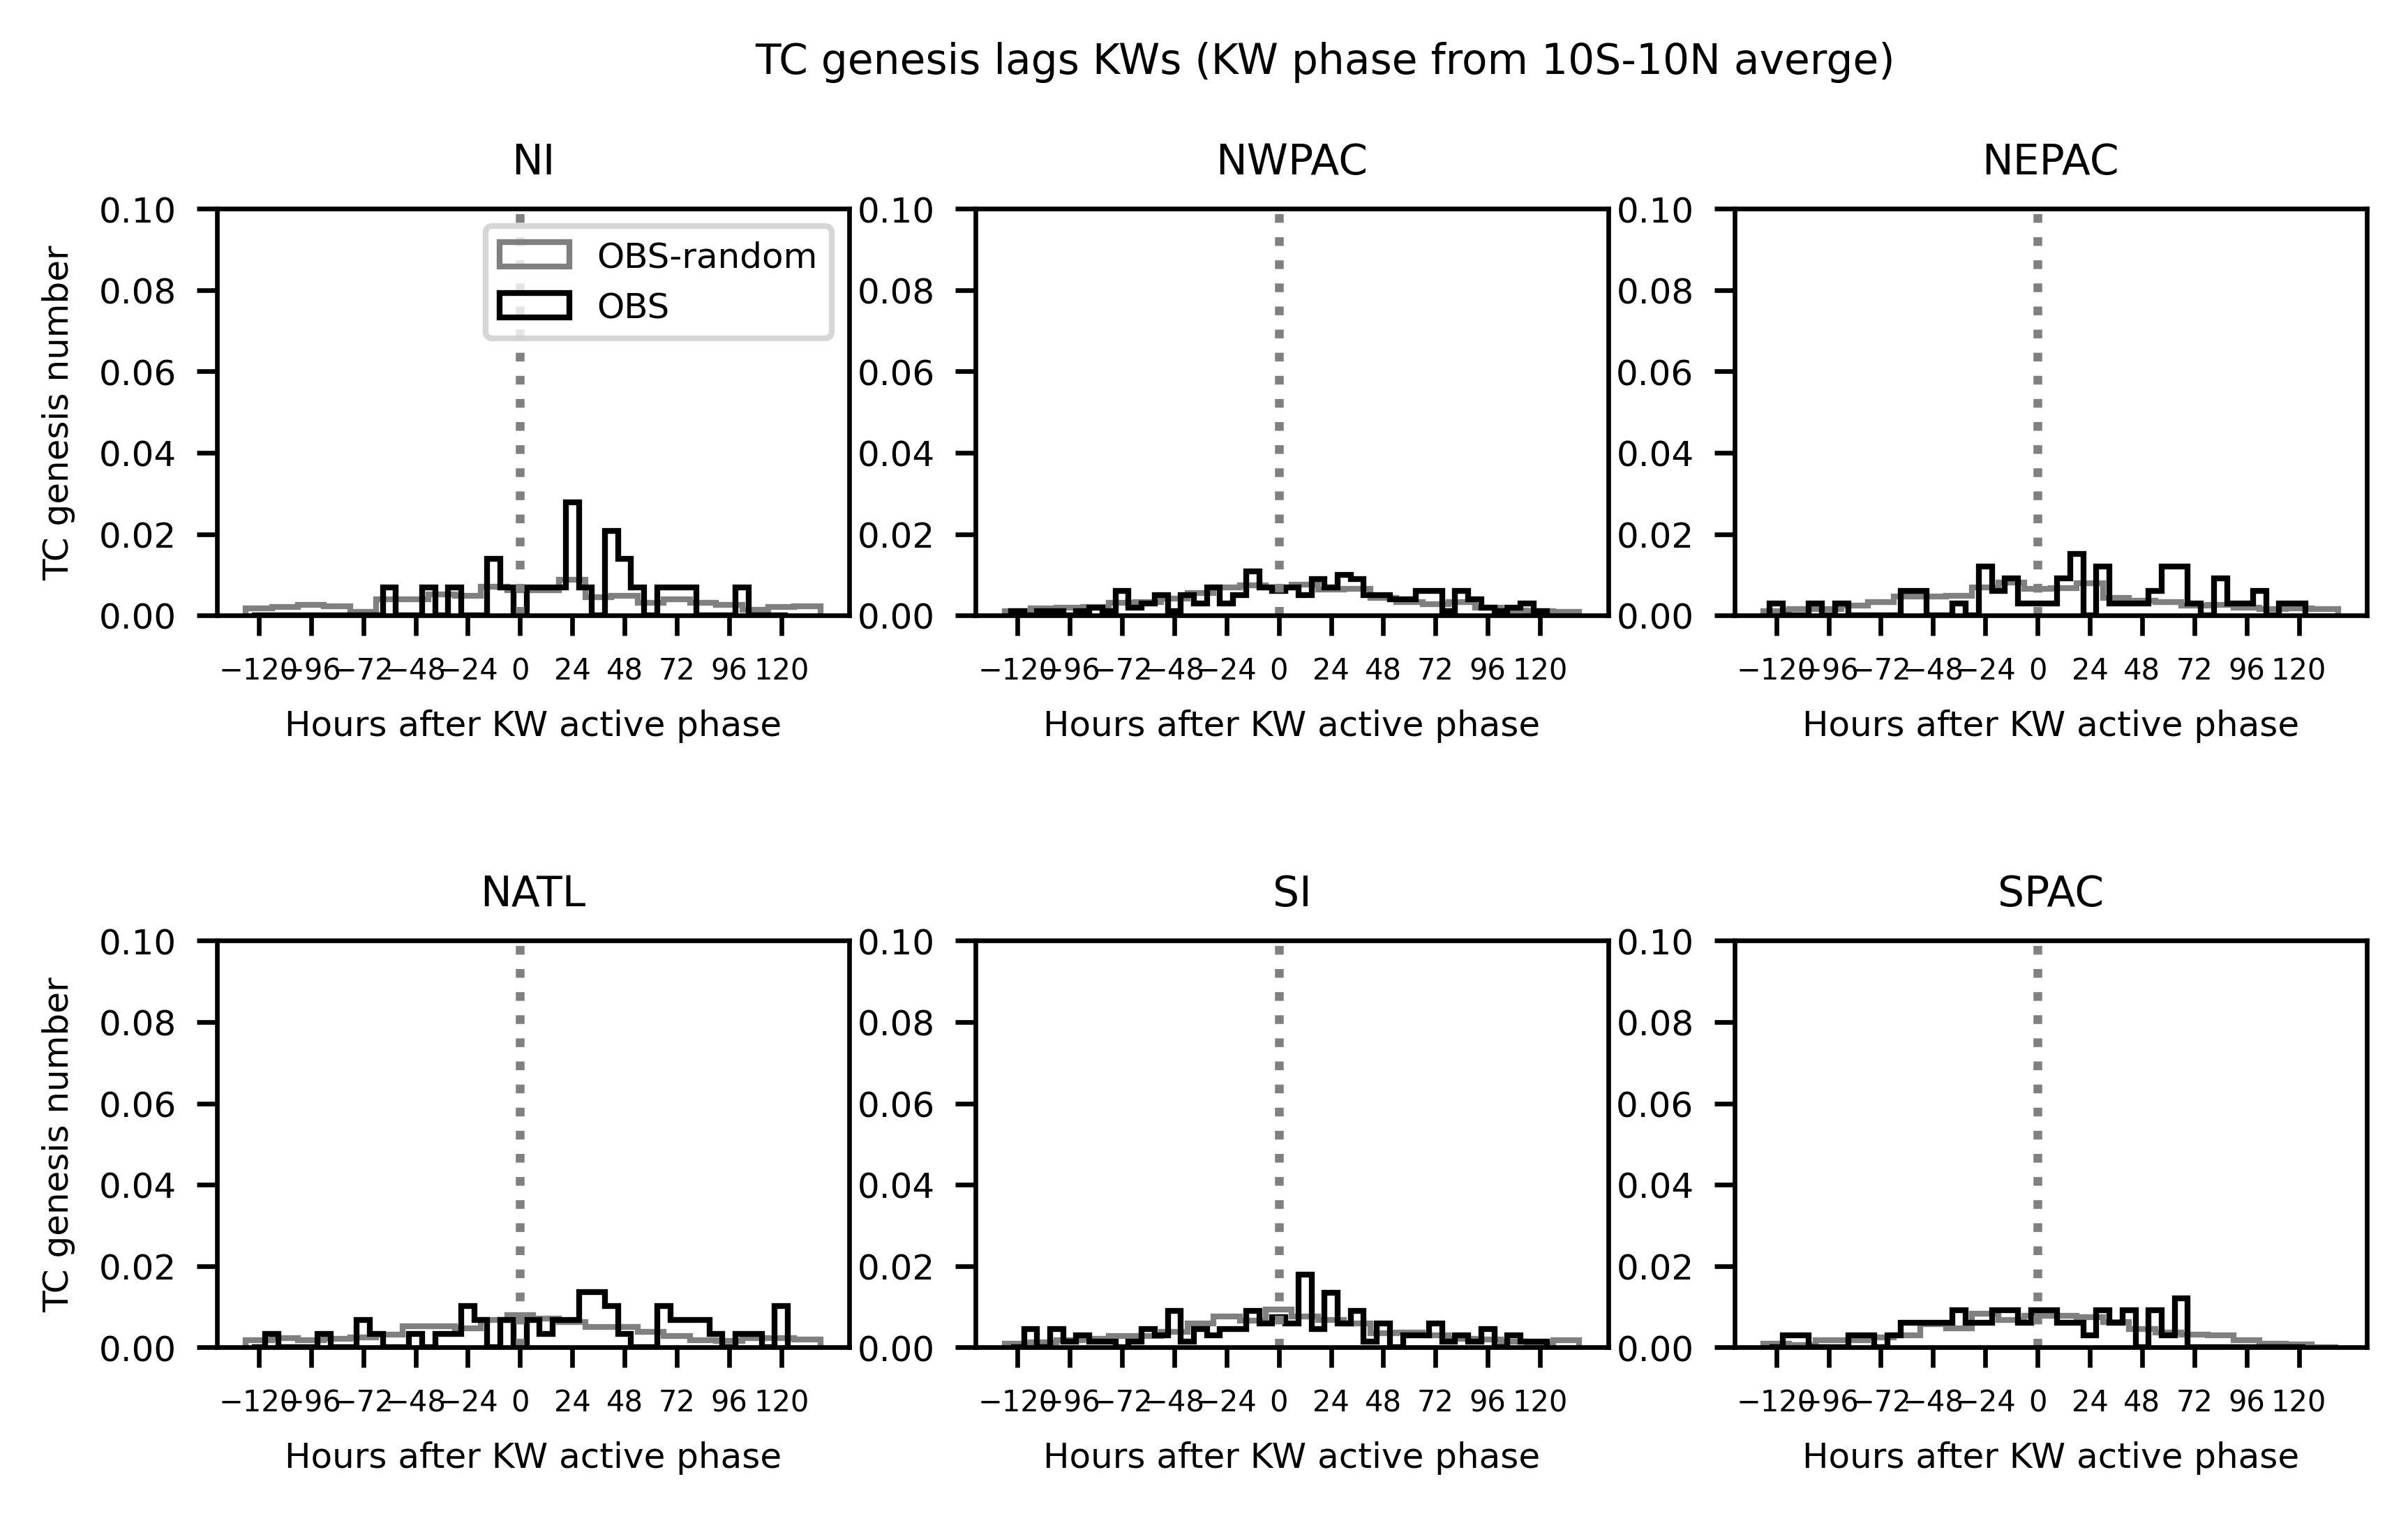

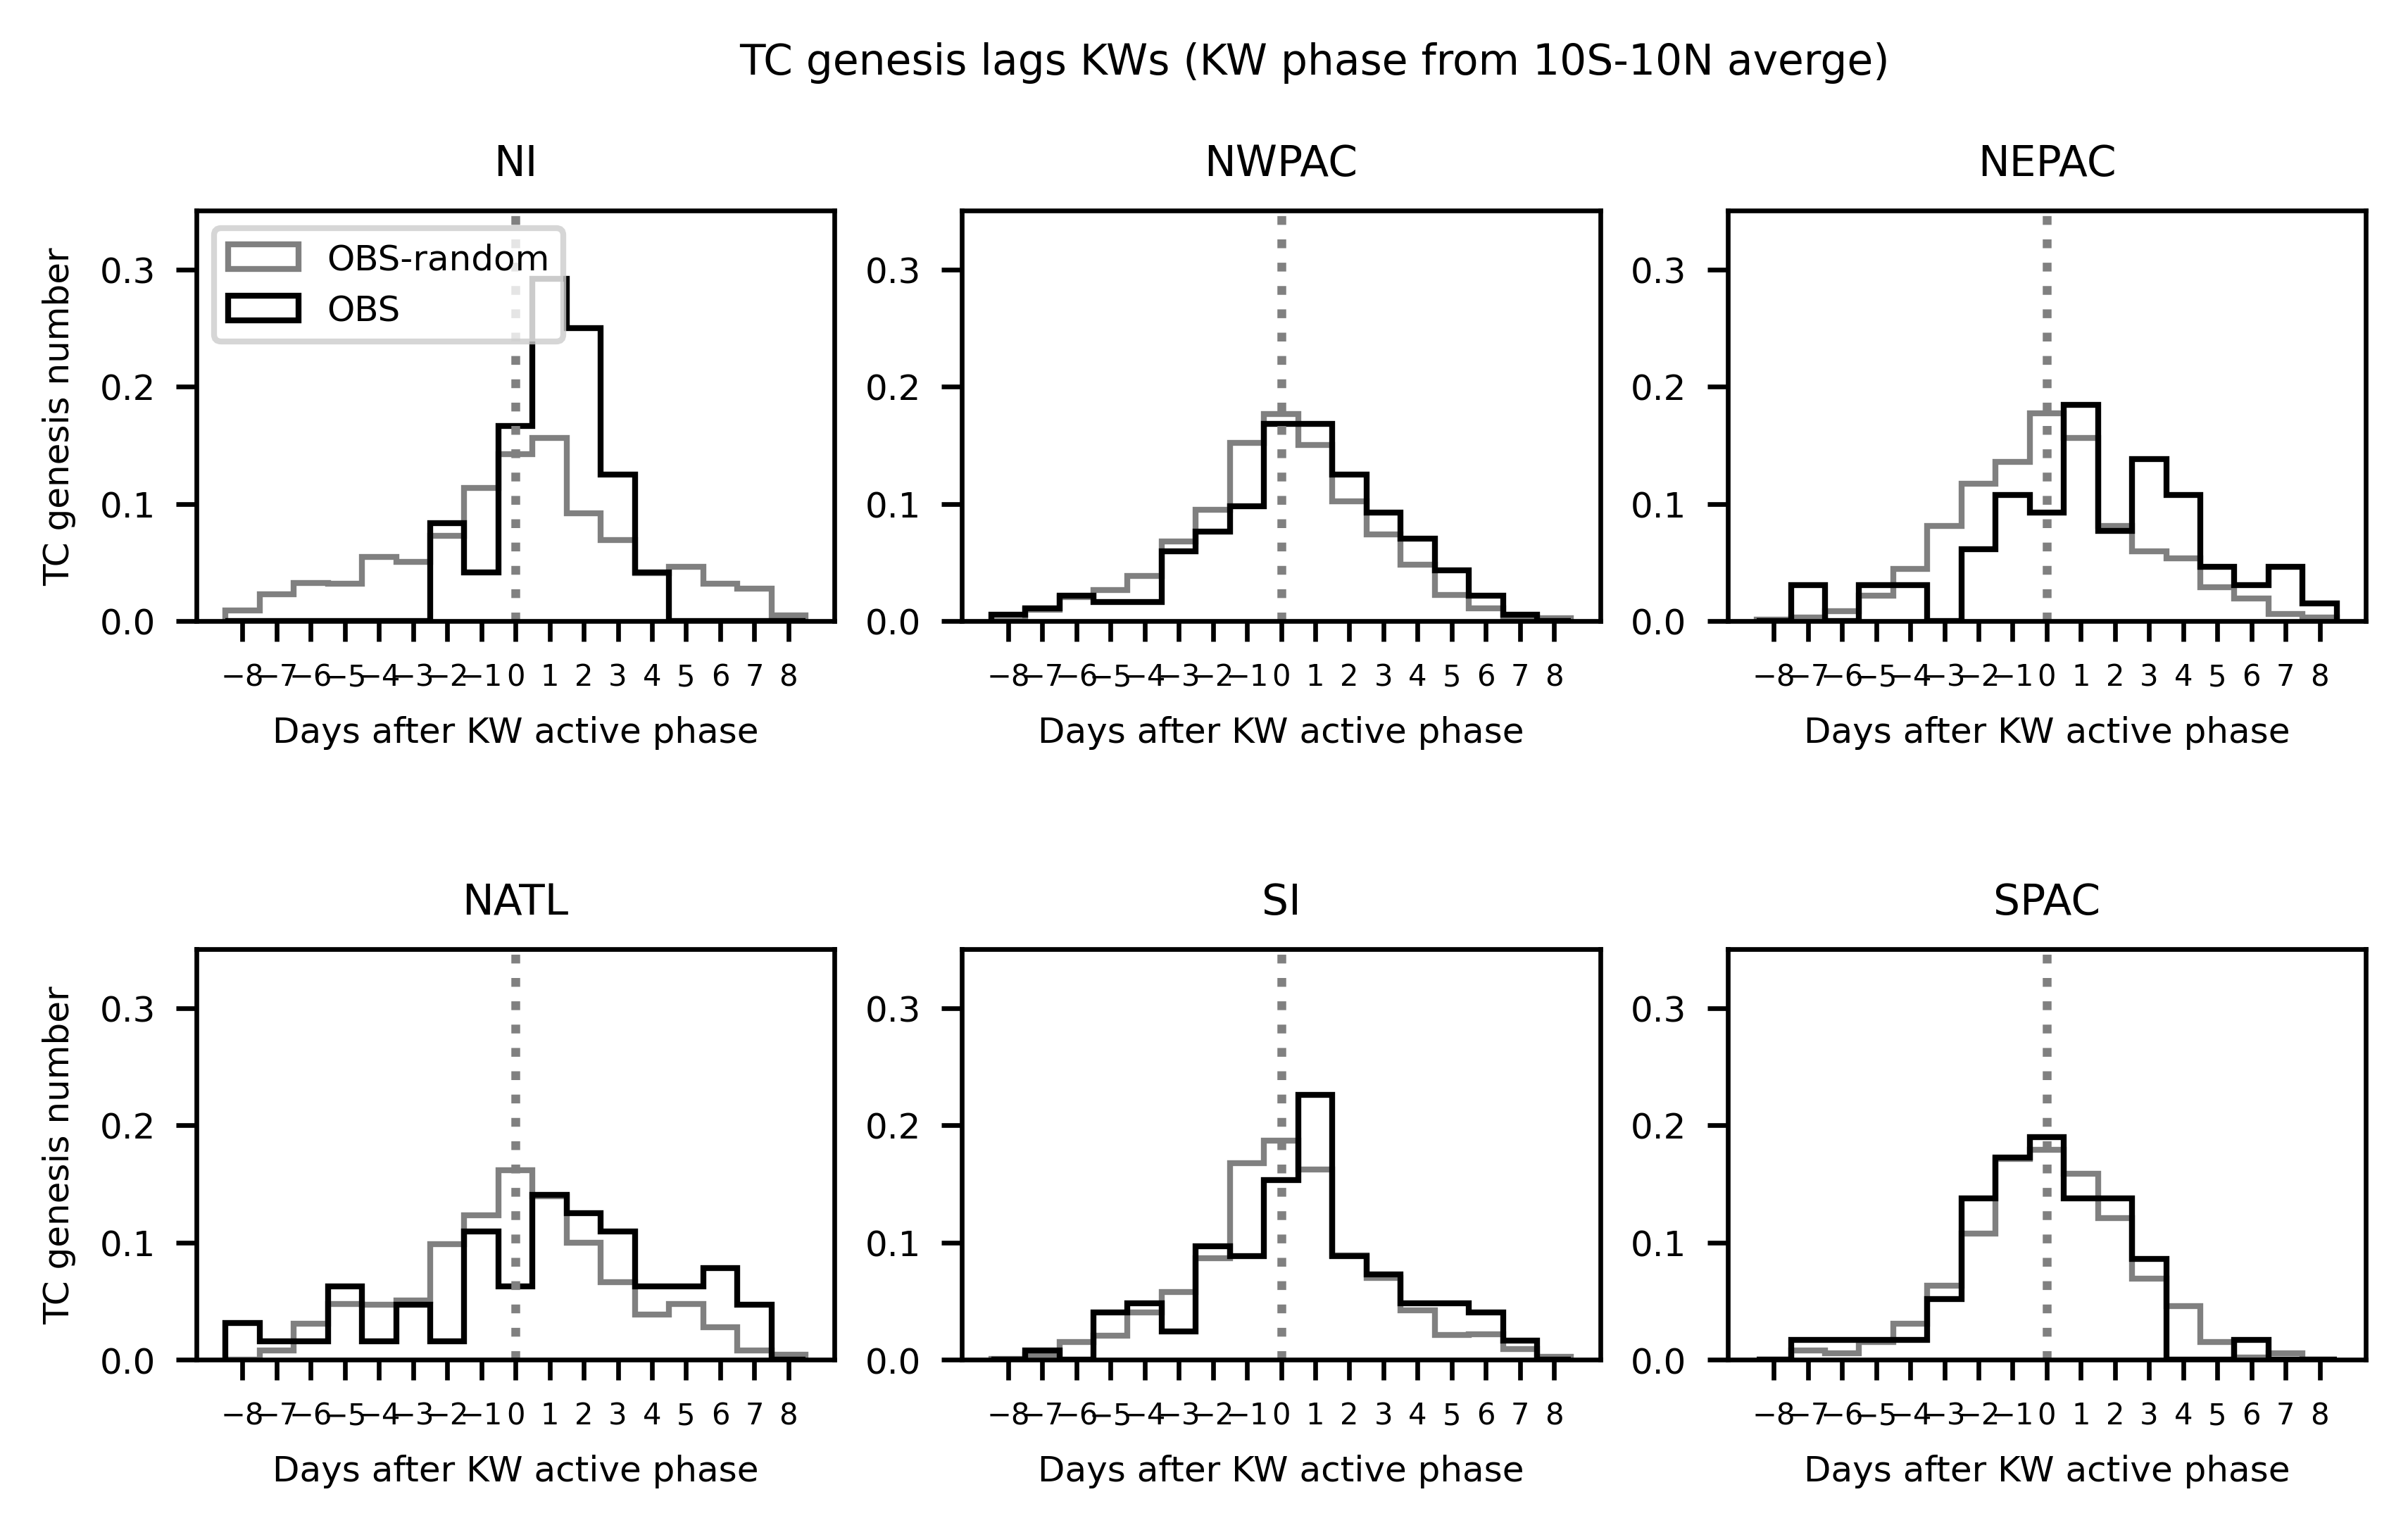

In [65]:
nbasin = 6
obs_only = 1 #0 or 1
ace2_only = 0 # 0 or 1
obs_only_list = list(['','_only_obs'])
ace2_only_list = list(['','_only_ace2'])
hr_bin_6h_12h = 1 # or 0 (0: 6h, 1: 12h)
hr_list = list(['','_12h'])
for bin_daily in range(0,2):
    if bin_daily == 0:
        fig_name = 'KW_TCgenesis_laghr_histogram_10SN_each_basin'+obs_only_list[obs_only]+ace2_only_list[ace2_only]+hr_list[hr_bin_6h_12h]+'.png'
    else:
        fig_name = 'KW_TCgenesis_laghr_histogram_10SN_daily_each_basin'+obs_only_list[obs_only]+ace2_only_list[ace2_only]+'.png'
    fig = plt.subplots(2,3,figsize=(6.5, 4),dpi=600)
    plt.subplots_adjust(left=0.2,right=0.99,top=0.88,bottom=0.2, hspace=0.8, wspace=0.2)
    plt.rcParams.update({'font.size': 6})
    zero = np.array([0,0])
    for ibasin in range(0, nbasin):
        plt.subplot(2, 3, ibasin+1)
        #dhr_tmp_ace2 = globals()['dhr_basin'+str(ibasin)+'_ace2']
        dhr_tmp_era5 = globals()['dhr_basin'+str(ibasin)+'_obs']
        #dhr_tmp_ace2_real = globals()['dhr_basin'+str(ibasin)+'_ace2_real']
        dhr_tmp_era5_real = globals()['dhr_basin'+str(ibasin)+'_obs_real']
        if bin_daily == 0:
            if obs_only == 0:
                if hr_bin_6h_12h == 0:
                    plt.hist(dhr_tmp_ace2, hr_bin, density=True, color='b',histtype='step')
                    #plt.plot([-117,117], [x_99_ace2_6hr_basin[ibasin], x_99_ace2_6hr_basin[ibasin]], color='dodgerblue', linewidth=0.5, linestyle='dashed')
                else:
                    plt.hist(dhr_tmp_ace2, hr_bin_12h, density=True, color='b',histtype='step')
                    #plt.plot([-117,117], [x_99_ace2_12hr_basin[ibasin], x_99_ace2_12hr_basin[ibasin]], color='dodgerblue', linewidth=0.5, linestyle='dashed')
            if ace2_only == 0:
                if hr_bin_6h_12h == 0:
                    plt.hist(dhr_tmp_era5, hr_bin, density=True, color='grey',label=':',histtype='step')
                    plt.hist(dhr_tmp_era5_real, hr_bin, density=True, color='k',label=':',histtype='step')
                    #plt.plot([-117,117], [x_99_obs_6hr_basin[ibasin], x_99_obs_6hr_basin[ibasin]], color='grey', linewidth=0.5, linestyle=':')
                else:
                    plt.hist(dhr_tmp_era5, hr_bin_12h, color='grey', density=True, label=':',histtype='step')
                    plt.hist(dhr_tmp_era5_real, hr_bin, density=True, color='k',label=':',histtype='step')
                    #plt.plot([-117,117], [x_99_obs_12hr_basin[ibasin], x_99_obs_12hr_basin[ibasin]], color='grey', linewidth=0.5, linestyle=':')
                #plt.hist(dhr_tmp_era5, hr_bin_12h, color='k',label=':',histtype='step')
                
            plt.xlabel('Hours after KW active phase')
            plt.xticks(np.arange(-120,144,24), fontsize=5)
            plt.plot(zero, [0,11], color='grey',linestyle=':')
            plt.ylim([0, 0.1])
        else:
            if obs_only == 0:
                plt.hist(dhr_tmp_era5/24, hr_bin_daily , color='grey', density=True, label=':',histtype='step')
                plt.hist(dhr_tmp_ace2_real/24, hr_bin_daily, density=True, color='b',histtype='step')
                #plt.plot([-8,8], [x_99_ace2_basin[ibasin], x_99_ace2_basin[ibasin]], color='dodgerblue', linewidth=0.5, linestyle='dashed')
            if ace2_only == 0:
                plt.hist(dhr_tmp_era5/24, hr_bin_daily, color='grey', density=True, label=':',histtype='step')
                plt.hist(dhr_tmp_era5_real/24, hr_bin_daily, density=True, color='k',label=':',histtype='step') 
                #plt.plot([-8,8], [x_99_obs_basin[ibasin], x_99_obs_basin[ibasin]], color='grey', linewidth=0.5, linestyle=':')
            plt.xlabel('Days after KW active phase')
            plt.xticks(np.arange(-8,9,1), fontsize=5)
            #plt.xticks(np.arange(-5,6,1), fontsize=5.5)
            plt.plot(zero, [0,1], color='grey',linestyle=':')
            plt.ylim([0, 0.35])
        

        
        if ibasin == 0:
            if obs_only == 1:
                plt.legend(['OBS-random','OBS'])
            if ace2_only == 1:
                plt.legend(['ACE2-ERA5'])
            if obs_only == 0 and ace2_only == 0:
                plt.legend(['ACE2-ERA5','OBS'])
        if ibasin == 0 or ibasin == 3:
            plt.ylabel('TC genesis number')
        plt.title(basin_list[ibasin])
    plt.suptitle('                                            TC genesis lags KWs (KW phase from 10S-10N averge)')
    #plt.savefig(fig_dir+fig_name,format='png', dpi=600)
    plt.show()
    plt.close()